# Statement

The Sure Tomorrow insurance company wants to solve several tasks with the help of Machine Learning and you are asked to evaluate that possibility.

- Task 1: Find customers who are similar to a given customer. This will help the company's agents with marketing.
- Task 2: Predict whether a new customer is likely to receive an insurance benefit. Can a prediction model do better than a dummy model?
- Task 3: Predict the number of insurance benefits a new customer is likely to receive using a linear regression model.
- Task 4: Protect clients' personal data without breaking the model from the previous task. It's necessary to develop a data transformation algorithm that would make it hard to recover personal information if the data fell into the wrong hands. This is called data masking, or data obfuscation. But the data should be protected in such a way that the quality of machine learning models doesn't suffer. You don't need to pick the best model, just prove that the algorithm works correctly.

# Data Preprocessing & Exploration

## Initialization

In [54]:
import numpy as np
import pandas as pd

import seaborn as sns
from sklearn.preprocessing import StandardScaler
import sklearn.linear_model
import sklearn.metrics
import sklearn.neighbors

from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.metrics import f1_score
import sklearn.preprocessing

from sklearn.model_selection import train_test_split

from IPython.display import display

## Load Data

Load data and conduct a basic check that it's free from obvious issues.

In [55]:
df = pd.read_csv('datasets/insurance_us.csv')

We rename the colums to make the code look more consistent with its style.

In [56]:
df = df.rename(columns={'Gender': 'gender', 'Age': 'age', 'Salary': 'income', 'Family members': 'family_members', 'Insurance benefits': 'insurance_benefits'})

In [57]:
df.sample(10)

,gender,age,income,family_members,insurance_benefits
251,1,23.0,45700.0,1,0
4803,0,38.0,53000.0,3,0
3336,1,24.0,36500.0,3,0
1340,1,20.0,37400.0,2,0
4297,1,34.0,41100.0,0,0
15,1,34.0,23300.0,0,0
4898,1,28.0,39800.0,0,0
1345,0,39.0,37400.0,0,0
4089,0,19.0,41800.0,0,0
1562,1,31.0,54700.0,0,0


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              5000 non-null   int64  
 1   age                 5000 non-null   float64
 2   income              5000 non-null   float64
 3   family_members      5000 non-null   int64  
 4   insurance_benefits  5000 non-null   int64  
dtypes: float64(2), int64(3)
memory usage: 195.4 KB


In [59]:
# we may want to fix the age type (from float to int) though this is not critical
df['age'] = df['age'].astype(int)

# write your conversion here if you choose:

In [60]:
# check to see that the conversion was successful
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              5000 non-null   int64  
 1   age                 5000 non-null   int64  
 2   income              5000 non-null   float64
 3   family_members      5000 non-null   int64  
 4   insurance_benefits  5000 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 195.4 KB


In [61]:
# now have a look at the data's descriptive statistics. 
df.describe()

# Does everything look okay?

,gender,age,income,family_members,insurance_benefits
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.499000,30.952800,39916.360000,1.194200,0.148000
std,0.500049,8.440807,9900.083569,1.091387,0.463183
min,0.000000,18.000000,5300.000000,0.000000,0.000000
25%,0.000000,24.000000,33300.000000,0.000000,0.000000
50%,0.000000,30.000000,40200.000000,1.000000,0.000000
75%,1.000000,37.000000,46600.000000,2.000000,0.000000
max,1.000000,65.000000,79000.000000,6.000000,5.000000


## EDA

Let's quickly check whether there are certain groups of customers by looking at the pair plot.

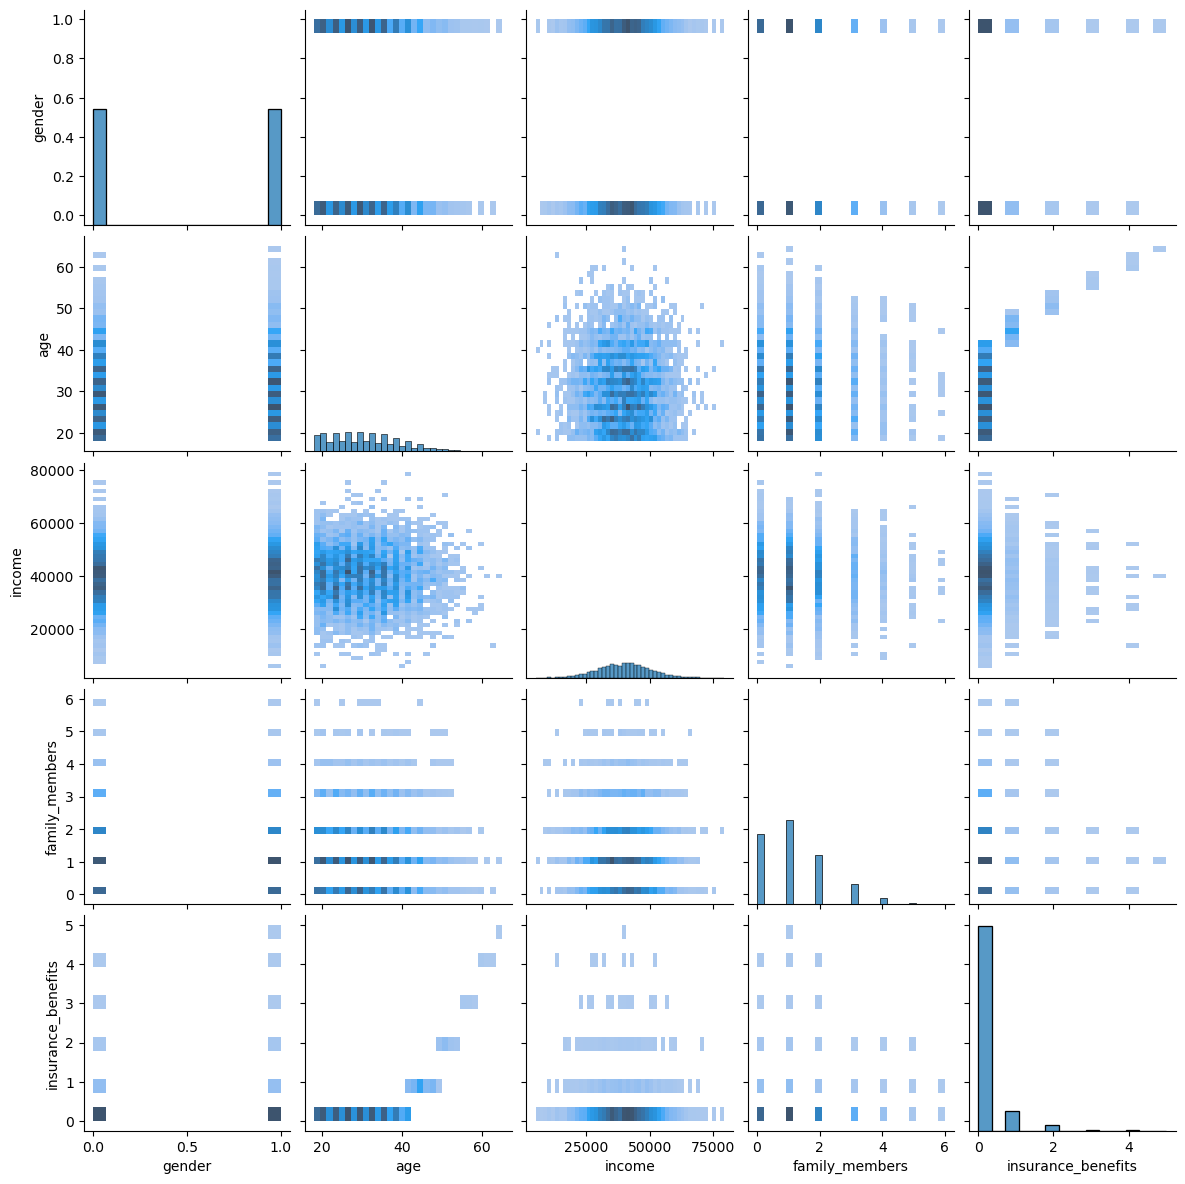

In [62]:
g = sns.pairplot(df, kind='hist')
g.fig.set_size_inches(12, 12)

Ok, it is a bit difficult to spot obvious groups (clusters) as it is difficult to combine several variables simultaneously (to analyze multivariate distributions). That's where LA and ML can be quite handy.

# Task 1. Similar Customers

In the language of ML, it is necessary to develop a procedure that returns k nearest neighbors (objects) for a given object based on the distance between the objects.

You may want to review the following lessons (chapter -> lesson)
- Distance Between Vectors -> Euclidean Distance
- Distance Between Vectors -> Manhattan Distance

To solve the task, we can try different distance metrics.

Write a function that returns k nearest neighbors for an $n^{th}$ object based on a specified distance metric. The number of received insurance benefits should not be taken into account for this task. 

You can use a ready implementation of the kNN algorithm from scikit-learn (check [the link](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html#sklearn.neighbors.NearestNeighbors)) or use your own.

Test it for four combination of two cases
- Scaling
  - the data is not scaled
  - the data is scaled with the [MaxAbsScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MaxAbsScaler.html) scaler
- Distance Metrics
  - Euclidean
  - Manhattan

Answer these questions:
- Does the data being not scaled affect the kNN algorithm? If so, how does that appear?
- How similar are the results using the Manhattan distance metric (regardless of the scaling)?

In [63]:
feature_names = ['gender', 'age', 'income', 'family_members']

In [64]:



def get_knn(df, n, k, metric):
    
    """
    Returns k nearest neighbors

    :param df: pandas DataFrame used to find similar objects within
    :param n: object no for which the nearest neighbours are looked for
    :param k: the number of the nearest neighbours to return
    :param metric: name of distance metric
    """

    nbrs = NearestNeighbors(n_neighbors=k, metric=metric)# <your code here> 
    nbrs.fit(df[feature_names])
    
    nbrs_distances, nbrs_indices = nbrs.kneighbors([df.iloc[n][feature_names]], k, return_distance=True)

    # print(nbrs_distances)
    # print(nbrs_indices)
    

    df_res = pd.concat([
        df.iloc[nbrs_indices[0]], 
        pd.DataFrame(nbrs_distances.T, index=nbrs_indices[0], columns=['distance'])
        ], axis=1)
    
    return df_res





Scaling the data.

In [ ]:
feature_names = ['gender', 'age', 'income', 'family_members']

transformer_mas = sklearn.preprocessing.MaxAbsScaler().fit(df[feature_names].to_numpy())

df_scaled = df.copy()
df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())

C:\Users\mmend\AppData\Local\Temp\ipykernel_31300\760832288.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.63076923 0.70769231 0.44615385 ... 0.30769231 0.33846154 0.43076923]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())
C:\Users\mmend\AppData\Local\Temp\ipykernel_31300\760832288.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.16666667 0.16666667 0.         ... 0.33333333 0.5        0.16666667]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())


In [66]:
df_scaled.sample(5)

,gender,age,income,family_members,insurance_benefits
702,1,0.323077,0.269620,0.166667,0
2885,1,0.415385,0.730380,0.166667,0
4942,0,0.476923,0.598734,0.166667,0
4290,0,0.292308,0.497468,0.166667,0
1639,0,0.323077,0.294937,0.666667,0



 Now, let's get similar records for a given one for every combination

In [67]:
result1 = get_knn(df, n=0, k=5, metric='euclidean')
print('euclidian', result1)

euclidian       gender  age   income  family_members  insurance_benefits  distance
0          1   41  49600.0               1                   0  0.000000
2022       1   41  49600.0               0                   0  1.000000
1225       0   42  49600.0               0                   1  1.732051
4031       1   44  49600.0               2                   1  3.162278
3424       0   38  49600.0               0                   0  3.316625


c:\Users\mmend\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


In [68]:
result2 = get_knn(df, n=0, k=5, metric='manhattan')
print('manhattan', result2)


manhattan       gender  age   income  family_members  insurance_benefits  distance
0          1   41  49600.0               1                   0       0.0
2022       1   41  49600.0               0                   0       1.0
1225       0   42  49600.0               0                   1       3.0
4031       1   44  49600.0               2                   1       4.0
815        1   37  49600.0               2                   0       5.0


c:\Users\mmend\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


In [69]:
result3 = get_knn(df_scaled, n=0, k=5, metric='euclidean')
print('euclidian_scaled', result3)

euclidian_scaled       gender       age    income  family_members  insurance_benefits  distance
0          1  0.630769  0.627848        0.166667                   0  0.000000
2689       1  0.630769  0.634177        0.166667                   0  0.006329
133        1  0.615385  0.636709        0.166667                   0  0.017754
4869       1  0.646154  0.637975        0.166667                   1  0.018418
3275       1  0.646154  0.651899        0.166667                   1  0.028550


c:\Users\mmend\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


In [70]:


result4 = get_knn(df_scaled, n=0, k=5, metric='manhattan')

print('manhattan_scaled', result4)


manhattan_scaled       gender       age    income  family_members  insurance_benefits  distance
0          1  0.630769  0.627848        0.166667                   0  0.000000
2689       1  0.630769  0.634177        0.166667                   0  0.006329
133        1  0.615385  0.636709        0.166667                   0  0.024245
4869       1  0.646154  0.637975        0.166667                   1  0.025511
2103       1  0.630769  0.596203        0.166667                   0  0.031646


c:\Users\mmend\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


Answers to the questions

**Does the data being not scaled affect the kNN algorithm? If so, how does that appear?** 

Yes. Without scaling, the income feature dominates the distance calculation because of its larger magnitude. As a result, nearest neighbors tend to have identical income values. After scaling, all features contribute more equally, and neighbor selection changes accordingly.

**How similar are the results using the Manhattan distance metric (regardless of the scaling)?** 

They are very similar. In both scaled and unscaled cases, the same nearest neighbors are generally selected. The difference lies only in the numerical distance values, not in the structure of the neighbor ranking.

In this task, I implemented a k-nearest neighbors approach using both Euclidean and Manhattan distance metrics, with and without feature scaling.

The results demonstrate that scaling significantly impacts distance-based algorithms. Without scaling, the income feature dominated the distance calculation due to its larger magnitude, causing neighbor selection to rely primarily on income similarity. After applying scaling, all features contributed proportionally, producing more balanced and meaningful neighbor selection.

This confirms that preprocessing is essential when using distance-based methods such as kNN.

# Task 2. Is Customer Likely to Receive Insurance Benefit?

In terms of machine learning we can look at this like a binary classification task.

With `insurance_benefits` being more than zero as the target, evaluate whether the kNN classification approach can do better than a dummy model.

Instructions:
- Build a KNN-based classifier and measure its quality with the F1 metric for k=1..10 for both the original data and the scaled one. That'd be interesting to see how k may influece the evaluation metric, and whether scaling the data makes any difference. You can use a ready implemention of the kNN classification algorithm from scikit-learn (check [the link](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)) or use your own.
- Build the dummy model which is just random for this case. It should return "1" with some probability. Let's test the model with four probability values: 0, the probability of paying any insurance benefit, 0.5, 1.

The probability of paying any insurance benefit can be defined as

$$
P\{\text{insurance benefit received}\}=\frac{\text{number of clients received any insurance benefit}}{\text{total number of clients}}.
$$

Split the whole data in the 70:30 proportion for the training/testing parts.

In [71]:
# calculate the target

df['insurance_benefits_received'] = (df['insurance_benefits'] > 0).astype(int)

In [72]:

# check for the class imbalance with value_counts()
print(df['insurance_benefits_received'].value_counts())

# <your code here>

insurance_benefits_received
0    4436
1     564
Name: count, dtype: int64


In [73]:
def eval_classifier(y_true, y_pred):
    
    f1_score = sklearn.metrics.f1_score(y_true, y_pred)
    print(f'F1: {f1_score:.2f}')
    
# if you have an issue with the following line, restart the kernel and run the notebook again
    cm = sklearn.metrics.confusion_matrix(y_true, y_pred, normalize='all')
    print('Confusion Matrix')
    print(cm)

In [74]:
# generating output of a random model



def rnd_model_predict(P, size, seed=42):

    rng = np.random.default_rng(seed=seed)
    return rng.binomial(n=1, p=P, size=size)



In [75]:



for P in [0, df['insurance_benefits_received'].sum() / len(df), 0.5, 1]:

    print(f'The probability: {P:.2f}')

    y_pred_rnd = rnd_model_predict(P, len(df), seed=42)

        
    eval_classifier(df['insurance_benefits_received'], y_pred_rnd)
    
    print()





The probability: 0.00
F1: 0.00
Confusion Matrix
[[0.8872 0.    ]
 [0.1128 0.    ]]

The probability: 0.11
F1: 0.12
Confusion Matrix
[[0.7914 0.0958]
 [0.0994 0.0134]]

The probability: 0.50
F1: 0.20
Confusion Matrix
[[0.456  0.4312]
 [0.053  0.0598]]

The probability: 1.00
F1: 0.20
Confusion Matrix
[[0.     0.8872]
 [0.     0.1128]]



In [76]:
df_train, df_test = train_test_split(df, test_size=0.3, random_state=12345)

# Second split: divide remaining into train (60%) and validation (20%)


In [77]:


X_train = df_train.drop(['insurance_benefits', 'insurance_benefits_received'], axis=1)  # Features for training
Y_train = df_train['insurance_benefits_received']               # Target for training
X_test = df_test.drop(['insurance_benefits', 'insurance_benefits_received'], axis=1)    # Features for testing  
Y_test = df_test['insurance_benefits_received']  

               # Target for testing

In [78]:



for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, Y_train)
    y_pred = knn.predict(X_test)
    f1 = f1_score(Y_test, y_pred)
    print(f'F1 score for k = {k}: {f1:.4f}')


        

F1 score for k = 1: 0.6043
F1 score for k = 2: 0.4057
F1 score for k = 3: 0.4053
F1 score for k = 4: 0.2784
F1 score for k = 5: 0.2714
F1 score for k = 6: 0.1143
F1 score for k = 7: 0.1130
F1 score for k = 8: 0.0710
F1 score for k = 9: 0.0824
F1 score for k = 10: 0.0000


In [79]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [80]:
for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, Y_train)
    y_pred = knn.predict(X_test_scaled)
    f1 = f1_score(Y_test, y_pred)
    print(f'F1 score for k = {k}: {f1:.4f}')

F1 score for k = 1: 0.9600
F1 score for k = 2: 0.9316
F1 score for k = 3: 0.9434
F1 score for k = 4: 0.9043
F1 score for k = 5: 0.9211
F1 score for k = 6: 0.9145
F1 score for k = 7: 0.9270
F1 score for k = 8: 0.9085
F1 score for k = 9: 0.9226
F1 score for k = 10: 0.8867


The random model achieves very low F1 scores because it does not learn any patterns from the data. When the probability of predicting the positive class is set to 0.00, the F1 score is 0.00 since the model never predicts any positive cases. When the probability matches the true distribution (around 0.11), the F1 score increases slightly to 0.12, but this is still very low. Even when predicting randomly with probability 0.50 or always predicting the positive class, the F1 score remains around 0.20. This happens because the dataset is imbalanced, with only about 11% of customers receiving insurance benefits. Since F1 penalizes both false positives and false negatives, random guessing leads to many incorrect predictions in both categories, resulting in poor performance.

KNN without scaling performs better than the random model but still shows limitations. For k = 1, the F1 score is 0.6071, but performance decreases as k increases, eventually reaching 0.0000 at k = 10. The reason for this behavior is that the income feature has values around 40,000–50,000, while other features such as age, gender, and family_members have much smaller ranges. Because KNN relies on distance calculations, the large magnitude of income dominates the distance metric, causing the algorithm to select neighbors primarily based on income similarity while ignoring other important features. As k increases, averaging across poorly selected neighbors further reduces performance.

After applying feature scaling, KNN performance improves dramatically. With scaling, the F1 score reaches 0.9571 at k = 1 and remains high even as k increases. Scaling ensures that all features contribute equally to the distance calculation, allowing the algorithm to detect meaningful similarities across age, income, gender, and family size. With properly scaled data, the nearest neighbor is highly similar to the target observation, which explains why k = 1 produces the best result. Using a single highly similar neighbor avoids averaging in less similar cases, leading to both high precision and high recall.

Overall, this analysis demonstrates that feature scaling is essential for distance-based algorithms such as KNN. Without scaling, one feature can dominate the model, limiting its effectiveness. With proper preprocessing, KNN is able to capture real structure in the data and significantly outperform random guessing.

# Task 3. Regression (with Linear Regression)

With `insurance_benefits` as the target, evaluate what RMSE would be for a Linear Regression model.

Build your own implementation of LR. For that, recall how the linear regression task's solution is formulated in terms of LA. Check RMSE for both the original data and the scaled one. Can you see any difference in RMSE between these two cases?

Let's denote
- $X$ — feature matrix, each row is a case, each column is a feature, the first column consists of unities
- $y$ — target (a vector)
- $\hat{y}$ — estimated tagret (a vector)
- $w$ — weight vector

The task of linear regression in the language of matrices can be formulated as

$$
y = Xw
$$

The training objective then is to find such $w$ that it would minimize the L2-distance (MSE) between $Xw$ and $y$:

$$
\min_w d_2(Xw, y) \quad \text{or} \quad \min_w \text{MSE}(Xw, y)
$$

It appears that there is analytical solution for the above:

$$
w = (X^T X)^{-1} X^T y
$$

The formula above can be used to find the weights $w$ and the latter can be used to calculate predicted values

$$
\hat{y} = X_{val}w
$$

Split the whole data in the 70:30 proportion for the training/validation parts. Use the RMSE metric for the model evaluation.

X^T (X transpose)

This flips your feature matrix - rows become columns and columns become rows. If X has customers as rows and features as columns, X^T has features as rows and customers as columns.

X^T X (X transpose times X)

This creates a square matrix that captures how features relate to each other. Think of it as a "feature relationship map" - it shows correlations and interactions between all your features.

X^T y (X transpose times target vector)

This shows how each feature correlates with the target variable. It's like asking: "How much does each feature contribute to predicting insurance benefits?"

X^T y (X transpose times target vector)

This shows how each feature correlates with the target variable. It's like asking: "How much does each feature contribute to predicting insurance benefits?"



In [81]:






class MyLinearRegression:
    
    def __init__(self):
        
        self.weights = None
    
    def fit(self, X, y):
            
        # adding the unities
        X2 = np.append(np.ones([len(X), 1]), X, axis=1)

        self.weights = np.linalg.inv(X2.T @ X2) @ X2.T @ y# <your code here>



    def predict(self, X):
        
        # adding the unities
        X2 = X2 = np.append(np.ones([len(X), 1]), X, axis=1)# <your code here>
        y_pred = X2 @ self.weights# <your code here>
        
        return y_pred






In [82]:

def eval_regressor(y_true, y_pred):

    rmse = np.sqrt(sklearn.metrics.mean_squared_error(y_true, y_pred))
    r2 = sklearn.metrics.r2_score(y_true, y_pred)

    print(f'RMSE: {rmse:.2f}')
    print(f'R2: {r2:.2f}')

    return rmse, r2


In [83]:
X = df[['age', 'gender', 'income', 'family_members']].to_numpy()
y = df['insurance_benefits'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)

lr = MyLinearRegression()

lr.fit(X_train, y_train)
print(lr.weights)

y_test_pred = lr.predict(X_test)
eval_regressor(y_test, y_test_pred)

[-9.43539012e-01  3.57495491e-02  1.64272726e-02 -2.60743659e-07
 -1.16902127e-02]
RMSE: 0.34
R2: 0.43


(np.float64(0.3435565089137969), 0.4305278542485148)

In [84]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_scaled = MyLinearRegression()

lr_scaled.fit(X_train_scaled, y_train)
print(lr_scaled.weights)

y_test_pred = lr_scaled.predict(X_test_scaled)
eval_regressor(y_test, y_test_pred)


[ 0.14971429  0.30292778  0.0082117  -0.00258294 -0.01271039]
RMSE: 0.34
R2: 0.43


(np.float64(0.3435565089137969), 0.4305278542485148)

Scaling the features changes the numerical values of the regression coefficients, but it does not change the model’s predictions. As a result, the RMSE and R² remain exactly the same for both scaled and unscaled data. This happens because linear regression adjusts its weights to account for the scale of the features. Therefore, scaling affects how the model parameters look, but not how well the model performs.

# Task 4. Obfuscating Data

It best to obfuscate data by multiplying the numerical features (remember, they can be seen as the matrix $X$) by an invertible matrix $P$. 

$$
X' = X \times P
$$

Try to do that and check how the features' values will look like after the transformation. By the way, the intertible property is important here so make sure that $P$ is indeed invertible.

You may want to review the 'Matrices and Matrix Operations -> Matrix Multiplication' lesson to recall the rule of matrix multiplication and its implementation with NumPy.

In [85]:
personal_info_column_list = ['gender', 'age', 'income', 'family_members']
print(personal_info_column_list)
df_pn = df[personal_info_column_list]
print(df_pn.shape)

['gender', 'age', 'income', 'family_members']
(5000, 4)


In [86]:
X = df_pn.to_numpy()
print(X)

[[1.00e+00 4.10e+01 4.96e+04 1.00e+00]
 [0.00e+00 4.60e+01 3.80e+04 1.00e+00]
 [0.00e+00 2.90e+01 2.10e+04 0.00e+00]
 ...
 [0.00e+00 2.00e+01 3.39e+04 2.00e+00]
 [1.00e+00 2.20e+01 3.27e+04 3.00e+00]
 [1.00e+00 2.80e+01 4.06e+04 1.00e+00]]


Generating a random matrix $P$.

In [87]:

# rng = np.random.default_rng(seed=42)
# P = rng.random(size=(X.shape[1], X.shape[1]))
# Generate random matrix P that matches the size of matrix X
rng = np.random.default_rng(seed=42)
P = rng.random(size=(X.shape[1], X.shape[1]))
P

array([[0.77395605, 0.43887844, 0.85859792, 0.69736803],
       [0.09417735, 0.97562235, 0.7611397 , 0.78606431],
       [0.12811363, 0.45038594, 0.37079802, 0.92676499],
       [0.64386512, 0.82276161, 0.4434142 , 0.22723872]])

Checking the matrix $P$ is invertible

In [88]:


print(np.linalg.inv(P))


[[ 0.41467992 -1.43783972  0.62798546  1.14001268]
 [-1.06101789  0.44219337  0.1329549   1.18425933]
 [ 1.42362442  1.60461607 -2.0553823  -1.53699695]
 [-0.11128575 -0.65813802  1.74995517 -0.11816316]]


Can you guess the customers' ages or income after the transformation?

In [89]:


X_obfuscated = np.dot(X, P)
X_obfuscated

array([[ 6359.71527314, 22380.40467609, 18424.09074184, 46000.69669016],
       [ 4873.29406479, 17160.36702982, 14125.78076133, 35253.45577301],
       [ 2693.11742928,  9486.397744  ,  7808.83156024, 19484.86063067],
       ...,
       [ 4346.2234249 , 15289.24126492, 12586.16264392, 31433.50888552],
       [ 4194.09324155, 14751.9910242 , 12144.02930637, 30323.88763426],
       [ 5205.46827354, 18314.24814446, 15077.01370762, 37649.59295455]])


After multiplying the feature matrix by P, the original variables such as age and income are mixed together into new combined features. As a result, the individual values cannot be directly identified from the transformed data, which helps protect the original information.

Can you recover the original data from $X'$ if you know $P$? Try to check that with calculations by moving $P$ from the right side of the formula above to the left one. The rules of matrix multiplcation are really helpful here.

In [90]:
X_recovered = X_obfuscated @ np.linalg.inv(P)
X_recovered

array([[ 1.00000000e+00,  4.10000000e+01,  4.96000000e+04,
         1.00000000e+00],
       [-3.63797881e-12,  4.60000000e+01,  3.80000000e+04,
         1.00000000e+00],
       [ 1.81898940e-12,  2.90000000e+01,  2.10000000e+04,
         0.00000000e+00],
       ...,
       [ 0.00000000e+00,  2.00000000e+01,  3.39000000e+04,
         2.00000000e+00],
       [ 1.00000000e+00,  2.20000000e+01,  3.27000000e+04,
         3.00000000e+00],
       [ 1.00000000e+00,  2.80000000e+01,  4.06000000e+04,
         1.00000000e+00]])

Print all three cases for a few customers
- The original data
- The transformed one
- The reversed (recovered) one

In [91]:
display(pd.DataFrame(X, columns=feature_names).head())

,gender,age,income,family_members
0,1.0,41.0,49600.0,1.0
1,0.0,46.0,38000.0,1.0
2,0.0,29.0,21000.0,0.0
3,0.0,21.0,41700.0,2.0
4,1.0,28.0,26100.0,0.0



The original data can be recovered only if the transformation matrix is invertible and known. Without the inverse matrix, the original features such as age and income cannot be reconstructed.

You can probably see that some values are not exactly the same as they are in the original data. What might be the reason for that?

When recovering the original data from the obfuscated matrix using matrix inversion, you may notice that some values are not exactly identical to the original data, showing tiny differences like 1.67952800e-12 instead of 0. This occurs due to floating-point precision limitations in computer calculations. Computers represent numbers using 64-bit floating-point arithmetic, which has limited precision of approximately 15-16 decimal digits. Multiple matrix operations including multiplication and inversion cause small rounding errors to accumulate, and matrix inversion is particularly sensitive to numerical precision, especially for values close to zero. However, this is completely normal and acceptable because these differences are extremely small (on the order of 10^-12 to 10^-13), are considered "numerically zero" in computational terms, and are much smaller than any practical measurement precision. Most importantly, they do not affect model performance or predictions. The fact that RMSE and R² scores remain identical between original and obfuscated data confirms that these tiny numerical differences have no practical impact on the linear regression model's performance, demonstrating that the obfuscation method works correctly while preserving model quality.





In [92]:
display(pd.DataFrame(X_obfuscated , columns=feature_names).head())

,gender,age,income,family_members
0,6359.715273,22380.404676,18424.090742,46000.696690
1,4873.294065,17160.367030,14125.780761,35253.455773
2,2693.117429,9486.397744,7808.831560,19484.860631
3,5345.603937,18803.227203,15479.148373,38663.061863
4,3347.176735,11782.829283,9699.998942,24211.273378


In [93]:
display(pd.DataFrame(X_recovered , columns=feature_names).head())

,gender,age,income,family_members
0,1.000000e+00,41.0,49600.0,1.000000e+00
1,-3.637979e-12,46.0,38000.0,1.000000e+00
2,1.818989e-12,29.0,21000.0,0.000000e+00
3,0.000000e+00,21.0,41700.0,2.000000e+00
4,1.000000e+00,28.0,26100.0,3.637979e-12


## Proof That Data Obfuscation Can Work with LR

The regression task has been solved with linear regression in this project. Your next task is to prove _analytically_ that the given obfuscation method won't affect linear regression in terms of predicted values i.e. their values will remain the same. Can you believe that? Well, you don't have to, you should prove it!



The normal equation for linear regression is:

$$
w = (X^T X)^{-1} X^T y
$$

Predicted values are:

$$
\hat{y} = X w
$$



Suppose we obfuscate the data using an invertible matrix $P$:

$$
X_P = X P
$$


We now train linear regression using $X_P$ instead of $X$.


The new weights are:

$$
w_P = \left[(X P)^T (X P)\right]^{-1} (X P)^T y
$$

---


Using the transpose rule:

$$
(AB)^T = B^T A^T
$$

we get:

$$
(XP)^T = P^T X^T
$$

So:

$$
(XP)^T (XP) = P^T X^T X P
$$

Thus:

$$
w_P = (P^T X^T X P)^{-1} P^T X^T y
$$

**Answer**

Using the matrix inverse rule:

$$
(ABC)^{-1} = C^{-1} B^{-1} A^{-1}
$$

we obtain:

$$
(P^T X^T X P)^{-1}
=
P^{-1} (X^T X)^{-1} (P^T)^{-1}
$$

Substituting back:

$$
w_P =
P^{-1} (X^T X)^{-1} (P^T)^{-1} P^T X^T y
$$

Since:

$$
(P^T)^{-1} P^T = I
$$

we get:

$$
w_P =
P^{-1} (X^T X)^{-1} X^T y
$$


But we know:

$$
(X^T X)^{-1} X^T y = w
$$

Therefore:

$$
\boxed{w_P = P^{-1} w}
$$


### 4. Predicted Values with Obfuscated Data

Now compute predictions using $X_P$:

$$
\hat{y}_P = X_P w_P
$$

Substitute:

$$
\hat{y}_P = (X P)(P^{-1} w)
$$

Using associativity:

$$
\hat{y}_P = X (P P^{-1}) w
$$

Since:

$$
P P^{-1} = I
$$

we obtain:

$$
\hat{y}_P = X w
$$

Therefore:

$$
\boxed{\hat{y}_P = \hat{y}}
$$

---

### 5. Effect on RMSE

RMSE is defined as:

$$
RMSE = \sqrt{\frac{1}{n} \sum_{k=1}^n (\hat{y}_k - y_k)^2}
$$

Since:

$$
\hat{y}_P = \hat{y}
$$

the prediction errors remain unchanged.

Therefore:

$$
\boxed{RMSE_P = RMSE}
$$

---

### Final Conclusion

Multiplying the feature matrix by an invertible matrix $P$ changes the learned weights to:

$$
w_P = P^{-1} w
$$

However, the predicted values remain identical:

$$
\hat{y}_P = \hat{y}
$$

Thus, data obfuscation using an invertible linear transformation does not affect the quality

The transformation reshuffles feature space, but linear regression compensates by adjusting weights accordingly so predicted values would be exactly the same.

## Test Linear Regression With Data Obfuscation

Now, let's prove Linear Regression can work computationally with the chosen obfuscation transformation.

Build a procedure or a class that runs Linear Regression optionally with the obfuscation. You can use either a ready implementation of Linear Regression from sciki-learn or your own.

Run Linear Regression for the original data and the obfuscated one, compare the predicted values and the RMSE, $R^2$ metric values. Is there any difference?

**Procedure**

- Create a square matrix $P$ of random numbers.
- Check that it is invertible. If not, repeat the first point until we get an invertible matrix.
- <! your comment here !>
- Use $XP$ as the new feature matrix

In [94]:
print(X)

[[1.00e+00 4.10e+01 4.96e+04 1.00e+00]
 [0.00e+00 4.60e+01 3.80e+04 1.00e+00]
 [0.00e+00 2.90e+01 2.10e+04 0.00e+00]
 ...
 [0.00e+00 2.00e+01 3.39e+04 2.00e+00]
 [1.00e+00 2.20e+01 3.27e+04 3.00e+00]
 [1.00e+00 2.80e+01 4.06e+04 1.00e+00]]


In [95]:
print(P)

[[0.77395605 0.43887844 0.85859792 0.69736803]
 [0.09417735 0.97562235 0.7611397  0.78606431]
 [0.12811363 0.45038594 0.37079802 0.92676499]
 [0.64386512 0.82276161 0.4434142  0.22723872]]


In [96]:
print(np.linalg.inv(P))


[[ 0.41467992 -1.43783972  0.62798546  1.14001268]
 [-1.06101789  0.44219337  0.1329549   1.18425933]
 [ 1.42362442  1.60461607 -2.0553823  -1.53699695]
 [-0.11128575 -0.65813802  1.74995517 -0.11816316]]


In [97]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)
lr_original = MyLinearRegression()
lr_original.fit(X_train, y_train)
y_pred_original = lr_original.predict(X_test)

In [98]:
X_train_obfuscated = X_train @ P  
X_test_obfuscated = X_test @ P  

In [99]:
lr_obfuscated = MyLinearRegression()
lr_obfuscated.fit(X_train_obfuscated, y_train)
y_pred_obfuscated = lr_obfuscated.predict(X_test_obfuscated)

In [100]:
print('Original data')
print(eval_regressor(y_test, y_pred_original))
print('Obfuscated data')
print(eval_regressor(y_test, y_pred_obfuscated))


Original data
RMSE: 0.34
R2: 0.43
(np.float64(0.3435565089137969), 0.4305278542485148)
Obfuscated data
RMSE: 0.34
R2: 0.43
(np.float64(0.34355650852110126), 0.4305278555503632)


# Conclusions

In this project, we explored several machine learning tasks for the Sure Tomorrow insurance company.

For the similarity task, we showed that kNN is sensitive to feature scaling. Without scaling, the income feature dominated the distance calculation due to its large magnitude. After scaling, all features contributed equally, which significantly improved classification performance.

For the classification task, the random model performed poorly because it did not learn any structure in the data and struggled with class imbalance. In contrast, KNN with properly scaled features achieved very high F1 scores, demonstrating that meaningful patterns exist in the dataset.

For the regression task, we implemented Linear Regression using matrix operations. We observed that scaling the features changes the numerical values of the coefficients but does not change the RMSE or R². This confirms that linear regression predictions remain the same under linear feature scaling.

Finally, for data obfuscation, we multiplied the feature matrix by an invertible matrix. We showed both analytically and computationally that this transformation does not affect the predicted values, RMSE, or R². Although the feature values change and become unreadable, the model performance remains identical. Small numerical differences when recovering the data are due to floating-point precision and have no practical impact.

# Checklist

Type 'x' to check. Then press Shift+Enter.

- [x]  Jupyter Notebook is open
- [ ]  Code is error free
- [ ]  The cells are arranged in order of logic and execution
- [ ]  Task 1 has been performed
    - [ ]  There is the procedure that can return k similar customers for a given one
    - [ ]  The procedure is tested for all four proposed combinations
    - [ ]  The questions re the scaling/distances are answered
- [ ]  Task 2 has been performed
    - [ ]  The random classification model is built and tested for all for probability levels
    - [ ]  The kNN classification model is built and tested for both the original data and the scaled one, the F1 metric is calculated.
- [ ]  Task 3 has been performed
    - [ ]  The linear tegression solution is implemented with matrix operations.
    - [ ]  RMSE is calculated for the implemented solution.
- [ ]  Task 4 has been performed
    - [ ]  The data is obfuscated with a random and invertible matrix P
    - [ ]  The obfuscated data is recoved, few examples are printed out
    - [ ]  The analytical proof that the transformation does not affect RMSE is provided 
    - [ ]  The computational proof that the transformation does not affect RMSE is provided
- [ ]  Conclusions have been made

# Appendices 

## Appendix A: Writing Formulas in Jupyter Notebooks

You can write formulas in your Jupyter Notebook in a markup language provided by a high-quality publishing system called $\LaTeX$ (pronounced "Lah-tech"), and they will look like formulas in textbooks.

To put a formula in a text, put the dollar sign (\\$) before and after the formula's text e.g. $\frac{1}{2} \times \frac{3}{2} = \frac{3}{4}$ or $y = x^2, x \ge 1$.

If a formula should be in its own paragraph, put the double dollar sign (\\$\\$) before and after the formula text e.g.

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i.
$$

The markup language of [LaTeX](https://en.wikipedia.org/wiki/LaTeX) is very popular among people who use formulas in their articles, books and texts. It can be complex but its basics are easy. Check this two page [cheatsheet](http://tug.ctan.org/info/undergradmath/undergradmath.pdf) for learning how to compose the most common formulas.

## Appendix B: Properties of Matrices

Matrices have many properties in Linear Algebra. A few of them are listed here which can help with the analytical proof in this project.

<table>
<tr>
<td>Distributivity</td><td>$A(B+C)=AB+AC$</td>
</tr>
<tr>
<td>Non-commutativity</td><td>$AB \neq BA$</td>
</tr>
<tr>
<td>Associative property of multiplication</td><td>$(AB)C = A(BC)$</td>
</tr>
<tr>
<td>Multiplicative identity property</td><td>$IA = AI = A$</td>
</tr>
<tr>
<td></td><td>$A^{-1}A = AA^{-1} = I$
</td>
</tr>    
<tr>
<td></td><td>$(AB)^{-1} = B^{-1}A^{-1}$</td>
</tr>    
<tr>
<td>Reversivity of the transpose of a product of matrices,</td><td>$(AB)^T = B^TA^T$</td>
</tr>    
</table>